In [4]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("customer_churn_processed.csv")

In [6]:
df.head()
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7032 non-null   int64  
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   float64
 5   PhoneService                           7032 non-null   int64  
 6   PaperlessBilling                       7032 non-null   int64  
 7   MonthlyCharges                         7032 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   MultipleLines_No phone service         7032 non-null   bool   
 10  MultipleLines_Yes                      7032 non-null   bool   
 11  InternetService

In [7]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [8]:
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7032, 30)
Target shape: (7032,)


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (5625, 30)
Testing Features: (1407, 30)
Training Target: (5625,)
Testing Target: (1407,)


In [11]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [12]:
print("Scaled Training Data:", X_train_scaled.shape)
print("Scaled Testing Data:", X_test_scaled.shape)

Scaled Training Data: (5625, 30)
Scaled Testing Data: (1407, 30)


In [13]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [14]:
y_pred = model.predict(X_test_scaled)
y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]

In [15]:
print("First 10 Predictions:")
print(y_pred[:10])

print("\nFirst 10 Churn Probabilities:")
print(y_pred_prob[:10])

First 10 Predictions:
[0 1 0 0 0 0 0 0 1 0]

First 10 Churn Probabilities:
[0.01711495 0.59613179 0.00476432 0.20004408 0.10022205 0.4700293
 0.02661132 0.16414898 0.68614136 0.01518016]


In [16]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Accuracy : 0.8038
Precision: 0.6476
Recall   : 0.5749
F1 Score : 0.6091
ROC-AUC  : 0.8357


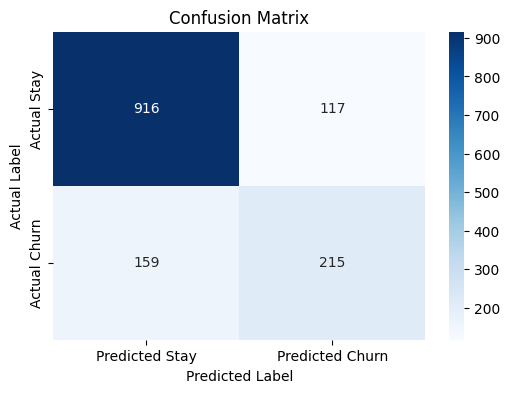

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Predicted Stay', 'Predicted Churn'],
            yticklabels=['Actual Stay', 'Actual Churn'])

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [21]:
print(type(model))
print(type(scaler))
print(type(X))

<class 'sklearn.linear_model._logistic.LogisticRegression'>
<class 'sklearn.preprocessing._data.StandardScaler'>
<class 'pandas.DataFrame'>


In [24]:
import joblib

joblib.dump(model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

['feature_columns.pkl']

In [23]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'customer_churn.csv', 'customer_churn_processed.csv', 'feature_columns.pkl', 'Feature_Engineering.ipynb', 'Machine_learning_model.ipynb', 'model.pkl', 'Python_EDA_Visual.ipynb', 'Retention_Priority_Scoring.ipynb', 'scaler.pkl']


# Business Observations
1.The Logistic Regression model achieved an accuracy of 80.38%, indicating strong overall predictive performance.
    
2.The model has a ROC-AUC score of 83.57%, showing good ability to separate customers who are likely to churn from those who are likely to stay.
    
3.The model correctly classified 916 loyal customers and 215 customers who eventually churned.
    
4.The model achieved a precision of 64.76%, meaning that nearly two-thirds of the customers predicted as churners actually churned.
    
5.The recall of 57.49% indicates that while the model successfully detects many churning customers, some churners are still missed.
    
6.The F1-score of 60.91% reflects a reasonable balance between precision and recall for this baseline model.


# Business Insights
1.The model enables the retention team to identify customers with a high probability of churning before they leave the company.

2.By correctly identifying 215 potential churners, the company can proactively offer discounts, personalized plans, or loyalty rewards to improve customer retention.

3.Since the model also correctly classified 916 loyal customers, unnecessary retention spending can be reduced for a large portion of the customer base.

4.The presence of 159 false negatives indicates that some customers at risk of churn are still being missed. Future improvements using more advanced algorithms (such as Random Forest or XGBoost) may help increase recall and reduce customer loss.

5.With a ROC-AUC score of 83.57%, the model demonstrates strong capability to rank customers by churn risk, making it useful for prioritizing retention campaigns.

# Conclusion:
A Logistic Regression model was developed to predict customer churn using the processed telecom dataset. The model achieved 80.38% accuracy and an ROC-AUC score of 83.57%, demonstrating good predictive performance. While it performs well in distinguishing churners from non-churners, improving the recall for churning customers remains an opportunity for future work. This baseline model provides a solid foundation for customer retention strategies and serves as a benchmark for evaluating more advanced machine learning algorithms.